# Clase 6 — Estadística para Data Science
### Diplomado de Python y Análisis de Datos — Universidad Marista

**Notebook único**: todos los bloques (00 a 09) en un solo archivo, en el mismo orden que la presentación, para que `df` y las demás variables se mantengan disponibles de principio a fin sin tener que cambiar de notebook.

Corre las celdas **en orden**, de arriba hacia abajo. Todo el código está comentado con `#` — ve descomentando bloque por bloque conforme avanzas en la clase.

> Nota: los bloques 07 y 09 cargan sus propios datasets en variables separadas (`df_exp` y `df_camp`) precisamente para no pisar el `df` general que se sigue usando después (por ejemplo en el bloque 08, Correlación).

---
## Bloque 00 — Setup

Clase 6 - Estadística para Data Science
Diplomado de Python y Análisis de Datos - Universidad Marista

In [1]:
#
#
# 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import zscore, ttest_ind

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/datos_generales.csv")

print(df.head())
print(df.shape)
df.info()

   id_cliente   ingreso categoria  publicidad  ventas
0           1  21092.04    Basico       34.49  149.97
1           2  13174.07    Basico       45.43  166.90
2           3  24653.10    Basico       39.65  135.05
3           4  26349.32  Estandar       59.03  178.83
4           5   9577.17  Estandar       39.82  106.69
(2000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  2000 non-null   int64  
 1   ingreso     2000 non-null   float64
 2   categoria   2000 non-null   object 
 3   publicidad  2000 non-null   float64
 4   ventas      1985 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 78.3+ KB


---
## Bloque 01 — Tendencia central (media, mediana, moda)

Media, mediana, moda
Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

### Media

In [ ]:
media = df["ventas"].mean()
print(media)

175.25976322418137


### Mediana

In [ ]:
mediana = df["ventas"].median()
print(mediana)

177.02


### Media vs mediana con "ingreso" (columna con sesgo positivo
por diseño: hay clientes con ingresos muy altos)

In [ ]:
media_ingreso = df["ingreso"].mean()
mediana_ingreso = df["ingreso"].median()

print("Media ingreso:", media_ingreso)
print("Mediana ingreso:", mediana_ingreso)

print("¿Cuál representa mejor al cliente típico?")

Media ingreso: 21304.475765
Mediana ingreso: 18917.795
¿Cuál representa mejor al cliente típico?


### Moda (variable categórica)

In [ ]:
moda = df["categoria"].mode()
print(moda)

frecuencias = df["categoria"].value_counts()
print(frecuencias)

0    Basico
Name: categoria, dtype: object
categoria
Basico         915
Estandar       596
Premium        349
Empresarial    140
Name: count, dtype: int64


---
## Bloque 02 — Dispersión (rango, varianza, desviación, CV)

Rango, varianza, desviación estándar, coeficiente de variación
Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

### Rango

In [ ]:
rango = df["ventas"].max() - df["ventas"].min()
print(rango)

351.12


### Varianza

In [ ]:
varianza = df["ventas"].var()
print(varianza)

2830.807394147538


### Desviación estándar

In [ ]:
desviacion = df["ventas"].std()
print(desviacion)

53.205332384522684


### Misma media, ¿diferente dispersión?
Comparemos "ventas" contra "publicidad" usando el
coeficiente de variación (medida relativa de dispersión).

In [ ]:
cv_ventas = df["ventas"].std() / df["ventas"].mean()
cv_publicidad = df["publicidad"].std() / df["publicidad"].mean()

print("CV ventas:", cv_ventas)
print("CV publicidad:", cv_publicidad)

CV ventas: 0.30357984859574266
CV publicidad: 0.30018876588341076


### Ejercicio para el grupo: construir dos sub-muestras
artificiales con la misma media pero distinta dispersión,
tal como el ejemplo Grupo A / Grupo B de la presentación,
y comprobarlo con .std()

In [ ]:
import numpy as np
grupo_a = np.array([48, 49, 50, 51, 52])
grupo_b = np.array([10, 30, 50, 70, 90])

print("Media A:", grupo_a.mean(), "Std A:", grupo_a.std(ddof=1))
print("Media B:", grupo_b.mean(), "Std B:", grupo_b.std(ddof=1))

Media A: 50.0 Std A: 1.5811388300841898
Media B: 50.0 Std B: 31.622776601683793


---
## Bloque 03 — Percentiles y distribuciones

Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

### Percentiles / cuartiles

In [ ]:
q1 = df["ventas"].quantile(0.25)
mediana = df["ventas"].quantile(0.50)
q3 = df["ventas"].quantile(0.75)
p95 = df["ventas"].quantile(0.95)

print(q1, mediana, q3, p95)

139.36 177.02 209.48 263.3179999999999


### Interpretación: ¿en qué percentil de "ingreso" está un
cliente con ingreso == 50000?

In [ ]:
import scipy.stats as stats
percentil_cliente = stats.percentileofscore(
     df["ingreso"].dropna(), 50000
 )
print(percentil_cliente)

98.7


### Visualizar la distribución de "ventas"

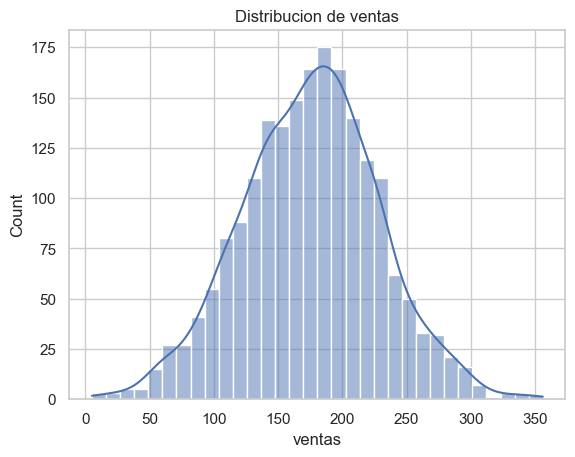

In [ ]:
sns.histplot(
     data=df,
     x="ventas",
     kde=True
)
plt.title("Distribucion de ventas")
plt.show()

### Visualizar la distribución de "ingreso" (sesgada a la
derecha por diseño) para comparar forma con "ventas"

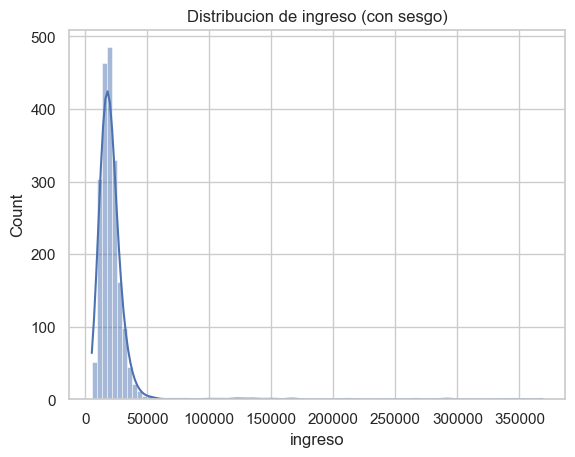

media ingreso: 21304.475765
mediana ingreso: 18917.795
¿media > mediana? -> señal de sesgo positivo


In [ ]:
sns.histplot(
     data=df,
     x="ingreso",
     kde=True
)
plt.title("Distribucion de ingreso (con sesgo)")
plt.show()

print("media ingreso:", df["ingreso"].mean())
print("mediana ingreso:", df["ingreso"].median())
print("¿media > mediana? -> señal de sesgo positivo")

---
## Bloque 04 — Z-score

Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

In [ ]:
df["z_ventas"] = zscore(
    df["ventas"].fillna(df["ventas"].mean())
)

print(
    df[["ventas", "z_ventas"]].head()
)

   ventas  z_ventas
0  149.97 -0.477237
1  166.90 -0.157755
2  135.05 -0.758788
3  178.83  0.067373
4  106.69 -1.293962


### Detección exploratoria de posibles valores extremos
(|z| > 3 como criterio de referencia, no una regla absoluta)

In [ ]:
posibles_extremos = df[df["z_ventas"].abs() > 3]
print(posibles_extremos)

      id_cliente   ingreso categoria  publicidad  ventas  z_ventas
150          151  17934.43   Premium      101.81  344.50  3.193689
187          188  12350.30   Premium       18.50   12.17 -3.077625
282          283  26228.54    Basico       77.66  338.30  3.076690
328          329  12579.17  Estandar       95.36  340.03  3.109337
477          478  12712.25  Estandar       86.40  352.68  3.348052
1636        1637  10220.73  Estandar        5.00    5.00 -3.212928
1768        1769  13749.89    Basico        5.00    5.00 -3.212928
1958        1959  17150.32   Premium       98.12  356.12  3.412967


### Repetir el ejercicio con "ingreso" (recuerden: esta columna
tiene sesgo positivo a propósito)

In [ ]:
df["z_ingreso"] = zscore(df["ingreso"])
extremos_ingreso = df[df["z_ingreso"].abs() > 3]
print(extremos_ingreso[["id_cliente", "ingreso", "z_ingreso"]])

      id_cliente    ingreso  z_ingreso
32            33  145541.26   6.538060
83            84  118083.22   5.093058
155          156  293537.06  14.326456
182          183  124010.58   5.404990
205          206  134212.87   5.941894
291          292  123717.13   5.389547
378          379  288833.61  14.078933
647          648   80778.45   3.129865
726          727  210971.75   9.981391
882          883  151976.68   6.876729
903          904  368789.13  18.286656
1065        1066  167333.45   7.684891
1086        1087  134590.99   5.961793
1460        1461  266864.69  12.922801
1578        1579   97239.75   3.996154
1683        1684  345603.71  17.066505
1905        1906  105457.71   4.428631
1967        1968  165915.73   7.610282


---
## Bloque 05 — Muestreo, Ley de los Grandes Números y CLT

     Y TEOREMA CENTRAL DEL LÍMITE (simulación)
Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

### Tomar una muestra con Pandas

In [ ]:
muestra = df.sample(
     n=100,
     random_state=42
)

media = muestra["ventas"].mean()
print(media)

181.74181818181816


### Cambiar la muestra (misma población, distinta semilla)

In [ ]:
muestra_1 = df.sample(n=100, random_state=42)
muestra_2 = df.sample(n=100, random_state=7)

print(muestra_1["ventas"].mean())
print(muestra_2["ventas"].mean())

181.74181818181816
166.5123232323232


### Comparar distintos tamaños de muestra
(Ley de los Grandes Números: al aumentar n, la media
muestral tiende a estabilizarse cerca de la media
poblacional)

In [ ]:
m10 = df.sample(10, random_state=1)["ventas"].mean()
m100 = df.sample(100, random_state=1)["ventas"].mean()
m1000 = df.sample(1000, random_state=1)["ventas"].mean()

print("n=10:", m10)
print("n=100:", m100)
print("n=1000:", m1000)
print("población completa:", df["ventas"].mean())

n=10: 168.353
n=100: 177.13819999999998
n=1000: 176.40001005025127
población completa: 175.25976322418137


### Simulando el Teorema Central del Límite
Población deliberadamente NO normal (exponencial), para
mostrar que la distribución de medias muestrales sí lo es.

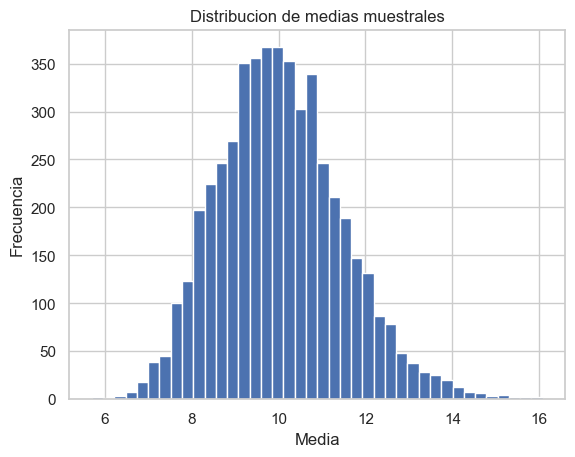

In [ ]:
poblacion = np.random.exponential(
    scale=10,
    size=100000
)

medias = []

for _ in range(5000):
    muestra = np.random.choice(poblacion, size=50)
    medias.append(muestra.mean())

plt.hist(medias, bins=40)
plt.title("Distribucion de medias muestrales")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.show()

### Variante: repetir la simulación anterior pero usando la
columna "ingreso" del propio dataset (que también tiene
sesgo) como población de origen.

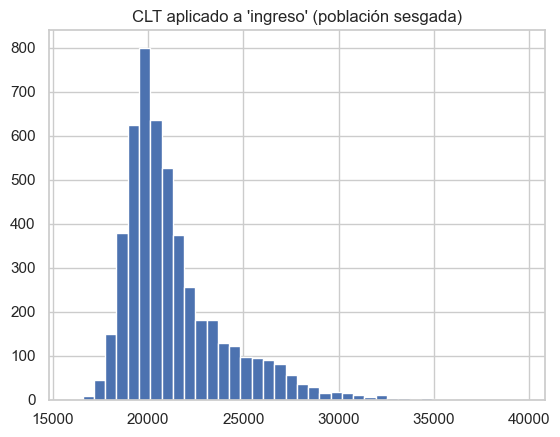

In [ ]:
poblacion_ingreso = df["ingreso"].dropna().values

medias_ingreso = []
for _ in range(5000):
    muestra = np.random.choice(poblacion_ingreso, size=50)
    medias_ingreso.append(muestra.mean())

plt.hist(medias_ingreso, bins=40)
plt.title("CLT aplicado a 'ingreso' (población sesgada)")
plt.show()

---
## Bloque 06 — Error estándar e intervalo de confianza

Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

### Error estándar manual
  SE = s / sqrt(n)

In [ ]:
datos = df["ventas"].dropna()

s = datos.std()
n = len(datos)
se = s / np.sqrt(n)

print("Desviación estándar:", s)
print("n:", n)
print("Error estándar:", se)

Desviación estándar: 53.205332384522684
n: 1985
Error estándar: 1.194194055794738


### Intervalo de confianza al 95% con SciPy

In [ ]:
media = datos.mean()
sem = stats.sem(datos)

ic = stats.t.interval(
     confidence=0.95,
     df=len(datos) - 1,
     loc=media,
     scale=sem
)

print("Media:", media)
print("IC 95%:", ic)

Media: 175.25976322418137
IC 95%: (np.float64(172.91775712828684), np.float64(177.6017693200759))


### ¿Qué pasa con el intervalo si usamos una muestra pequeña
en lugar de todos los datos? (más ancho = menos precisión)

In [ ]:
# muestra_chica = datos.sample(30, random_state=3)
# media_chica = muestra_chica.mean()
# sem_chica = stats.sem(muestra_chica)

# ic_chica = stats.t.interval(
#     confidence=0.95,
#     df=len(muestra_chica) - 1,
#     loc=media_chica,
#     scale=sem_chica
# )

# print("IC 95% con n=30:", ic_chica)
# print("Ancho n=30:", ic_chica[1] - ic_chica[0])
# print("Ancho con todos los datos:", ic[1] - ic[0])

IC 95% con n=30: (np.float64(153.9030797033195), np.float64(189.16558696334718))
Ancho n=30: 35.26250726002769
Ancho con todos los datos: 4.684012191789066


---
## Bloque 07 — Caso práctico: Experimento A/B (Welch t-test)

Dataset: data/experimento_marketing.csv
Columnas: id_usuario, grupo (A/B), gasto



### Paso 1: cargar el dataset

In [ ]:
# import pandas as pd
# from scipy.stats import ttest_ind

# df_exp = pd.read_csv("data/experimento_marketing.csv")

# print(df_exp.head())
# print(df_exp.shape)
# df_exp.info()

### Paso 2: descriptiva por grupo

In [ ]:
# resumen = (
#     df_exp.groupby("grupo")["gasto"]
#       .agg(["count", "mean", "median", "std"])
# )
# print(resumen)

### Paso 3: visualizar

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_exp, x="grupo", y="gasto")
plt.title("Distribucion del gasto por grupo")
plt.show()

NameError: name 'df_exp' is not defined

### Pregunta antes de probar:
¿Parece existir una diferencia? Recuerda: una diferencia
visual no demuestra por sí sola una diferencia estadística.

### Paso 4: separar grupos

In [ ]:
# grupo_a = df_exp.loc[df_exp["grupo"] == "A", "gasto"].dropna()
# grupo_b = df_exp.loc[df_exp["grupo"] == "B", "gasto"].dropna()

# print(grupo_a.mean())
# print(grupo_b.mean())

### Formular hipótesis
  H0: mu_A = mu_B
  H1: mu_A != mu_B

### Paso 5: Welch t-test

In [ ]:
# t_stat, p_value = ttest_ind(
#     grupo_a,
#     grupo_b,
#     equal_var=False
# )

# print("t-statistic:", t_stat)
# print("p-value:", p_value)

### Paso 6: decisión estadística

In [ ]:
# alpha = 0.05

# if p_value < alpha:
#     print("Hay evidencia de una diferencia.")
# else:
#     print("No hay evidencia suficiente.")

### Paso 7: diferencia observada (magnitud)

In [ ]:
# media_a = grupo_a.mean()
# media_b = grupo_b.mean()
# diferencia = media_b - media_a

# print("Media A:", media_a)
# print("Media B:", media_b)
# print("Diferencia:", diferencia)

### Extra: tamaño del efecto (Cohen's d, con varianza combinada)

In [ ]:
# import numpy as np

# n_a, n_b = len(grupo_a), len(grupo_b)
# s_pooled = np.sqrt(
#     (
#         (n_a - 1) * grupo_a.std(ddof=1) ** 2
#         + (n_b - 1) * grupo_b.std(ddof=1) ** 2
#     )
#     / (n_a + n_b - 2)
# )

# cohen_d = (media_b - media_a) / s_pooled
# print("Cohen's d:", cohen_d)
# print("(referencia orientativa: ~0.2 pequeño, ~0.5 mediano, ~0.8 grande)")

---
## Bloque 08 — Correlación

Dataset: data/datos_generales.csv
Requiere: haber corrido 00_setup.py (df cargado)

In [ ]:
# correlacion = df[["publicidad", "ventas"]].corr()
# print(correlacion)

### Visualizar la relación

In [ ]:
# sns.scatterplot(data=df, x="publicidad", y="ventas")
# plt.title("Publicidad vs Ventas")
# plt.show()

### Recordatorio: correlación no implica causalidad.
Pregunta para el grupo: ¿qué terceras variables podrían
explicar la relación entre publicidad y ventas, además de
un efecto directo de la publicidad?

---
## Bloque 09 — Statistical Detective Challenge

Dataset: data/campania_ab.csv
Columnas: id_usuario, grupo, edad, region, conversion,
          gasto, tiempo_sitio

Marketing afirma: "La campaña B es mejor que la campaña A."
Misión de los equipos: determinar si los datos respaldan
esa afirmación.

Este script es un ESQUELETO guiado (Pasos 1-5 de la
presentación). Los equipos deben ir descomentando y
completando lo que falta (marcado con "# TODO").

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.stats import ttest_ind

# df_camp = pd.read_csv("data/campania_ab.csv")

### Paso 1: explorar
  - tamaño de los grupos
  - media, mediana, desviación estándar
  - valores faltantes
  - posibles outliers

In [ ]:
# print(df_camp.shape)
# df_camp.info()
# print(df_camp.isna().sum())

# resumen = (
#     df_camp.groupby("grupo")["gasto"]
#       .agg(["count", "mean", "median", "std"])
# )
# print(resumen)

# TODO: ¿los tamaños de muestra de A y B son parecidos?
# TODO: ¿qué tan distinta es la media de la mediana en cada grupo?
#       (una gran diferencia entre media y mediana suele ser
#       señal de sesgo u outliers)

### Paso 2: visualizar
Cada equipo debe crear al menos una gráfica (boxplot,
histograma o comparación de medias).

In [ ]:
# sns.boxplot(data=df_camp, x="grupo", y="gasto")
# plt.title("Distribucion del gasto por grupo")
# plt.show()

# TODO: probar también un histograma por grupo, por ejemplo:
# sns.histplot(data=df_camp, x="gasto", hue="grupo", kde=True)
# plt.show()

### Paso 3: formular hipótesis
  H0: mu_A = mu_B
  H1: mu_A != mu_B
Explicar en lenguaje de negocio qué significaría cada una.

### Paso 4: realizar la prueba (Welch t-test)
Reportar: estadístico t, valor p, alpha, decisión.

In [ ]:
# grupo_a = df_camp.loc[df_camp["grupo"] == "A", "gasto"].dropna()
# grupo_b = df_camp.loc[df_camp["grupo"] == "B", "gasto"].dropna()

# t_stat, p_value = ttest_ind(grupo_a, grupo_b, equal_var=False)
# alpha = 0.05

# print("t-statistic:", t_stat)
# print("p-value:", p_value)

# if p_value < alpha:
#     print("Hay evidencia de una diferencia.")
# else:
#     print("No hay evidencia suficiente.")

### Paso 5: medir la diferencia
No basta con reportar el valor p; hay que calcular la
magnitud y preguntarse si es relevante para el negocio.

In [ ]:
# diferencia = grupo_b.mean() - grupo_a.mean()
# print("Diferencia de medias:", diferencia)

# TODO: comparar también la diferencia de MEDIANAS.
# diferencia_mediana = grupo_b.median() - grupo_a.median()
# print("Diferencia de medianas:", diferencia_mediana)

# TODO (pista para el equipo): investiguen si un pequeño
# número de observaciones con gasto muy alto en algún grupo
# está influyendo desproporcionadamente en la media. Pueden
# revisar los valores más altos con:
# print(df_camp.sort_values("gasto", ascending=False).head(10))

### Formato de entrega (recordatorio):
  1. pregunta
  2. hipótesis
  3. resumen descriptivo
  4. visualización
  5. prueba estadística
  6. valor p
  7. diferencia observada
  8. interpretación
  9. recomendación